# Model Training — Harmonization, Feature Engineering & Linear Regression

This notebook executes 3 phases:
1. **A.2** — Harmonization and unification of the 5 CSVs → `data/processed/unified.csv`
2. **A.3** — Feature engineering (selection of 6 features + correlation heatmap)
3. **A.4** — Pipeline Training (StandardScaler + LinearRegression) → `models/model.pkl`, `data/processed/train.csv`, `data/processed/test.csv`

## Section 1 — Harmonization and Unification (Step A.2)

In [ ]:
# Imports for harmonization
import sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from src.paths import DATA_RAW, DATA_PROCESSED

# Column mapping per year: original_name -> unified_name
COLUMN_MAP = {
    2015: {
        "Country": "country", "Region": "region",
        "Happiness Score": "happiness_score",
        "Economy (GDP per Capita)": "gdp", "Family": "family",
        "Health (Life Expectancy)": "health", "Freedom": "freedom",
        "Trust (Government Corruption)": "corruption", "Generosity": "generosity",
    },
    2016: {
        "Country": "country", "Region": "region",
        "Happiness Score": "happiness_score",
        "Economy (GDP per Capita)": "gdp", "Family": "family",
        "Health (Life Expectancy)": "health", "Freedom": "freedom",
        "Trust (Government Corruption)": "corruption", "Generosity": "generosity",
    },
    2017: {
        "Country": "country", "Happiness.Score": "happiness_score",
        "Economy..GDP.per.Capita.": "gdp", "Family": "family",
        "Health..Life.Expectancy.": "health", "Freedom": "freedom",
        "Trust..Government.Corruption.": "corruption", "Generosity": "generosity",
    },
    2018: {
        "Country or region": "country", "Score": "happiness_score",
        "GDP per capita": "gdp", "Social support": "family",
        "Healthy life expectancy": "health",
        "Freedom to make life choices": "freedom",
        "Perceptions of corruption": "corruption", "Generosity": "generosity",
    },
    2019: {
        "Country or region": "country", "Score": "happiness_score",
        "GDP per capita": "gdp", "Social support": "family",
        "Healthy life expectancy": "health",
        "Freedom to make life choices": "freedom",
        "Perceptions of corruption": "corruption", "Generosity": "generosity",
    },
}

UNIFIED_COLUMNS = ["country", "year", "region", "gdp", "family",
                   "health", "freedom", "generosity", "corruption", "happiness_score"]

### Output Interpretation
The required libraries and centralized path variables were successfully loaded, preparing the environment for data harmonization and model training.

In [ ]:
def load_and_normalize(year: int) -> pd.DataFrame:
    """Read one CSV and rename columns to the unified schema."""
    raw = pd.read_csv(DATA_RAW / f"{year}.csv")
    df = raw.rename(columns=COLUMN_MAP[year])
    df["year"] = year
    # Add missing region as NaN for 2017-2019
    if "region" not in df.columns:
        df["region"] = np.nan
    # Coerce corruption to numeric (2018 has a string NaN)
    df["corruption"] = pd.to_numeric(df["corruption"], errors="coerce")
    return df[UNIFIED_COLUMNS]

### Output Interpretation
The harmonization function has been defined. It will process each dataset by renaming its heterogeneous columns into a unified standard schema and imputing the missing value found in the 2018 dataset.

In [ ]:
# Build unified dataframe
unified = pd.concat([load_and_normalize(y) for y in range(2015, 2020)], ignore_index=True)

# Impute region using the 2015 country->region mapping
country_region = (unified[unified["year"] == 2015]
                  .set_index("country")["region"].to_dict())
unified["region"] = unified.apply(
    lambda r: r["region"] if pd.notna(r["region"]) else country_region.get(r["country"]),
    axis=1,
)
unified["region"] = unified["region"].fillna("Unknown")

# Impute corruption NaN (UAE 2018) with that year's mean
unified["corruption"] = unified.groupby("year")["corruption"].transform(
    lambda s: s.fillna(s.mean())
)

# Persist unified dataset
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
unified.to_csv(DATA_PROCESSED / "unified.csv", index=False)
print(unified.shape, "nulos:", unified.isna().sum().sum())

(782, 10) nulos: 0


### Output Interpretation
The datasets from 2015 to 2019 have been successfully unified into a single DataFrame. The resulting dataset contains 782 rows and 10 columns, with exactly 0 missing values, confirming that the harmonization and imputation processes worked perfectly.

In [ ]:
# Test: validate unification
df = pd.read_csv(DATA_PROCESSED / "unified.csv")
assert df.shape[0] >= 780, f"Pocas filas: {df.shape[0]}"
assert df[["gdp","family","health","freedom","generosity","corruption","happiness_score"]].isna().sum().sum() == 0
print("OK unification")

OK unification


### Output Interpretation
The automated assertion test passed, confirming that the `unified.csv` file was correctly saved to disk and has the expected shape and columns.

## Section 2 — Feature Engineering (Step A.3)

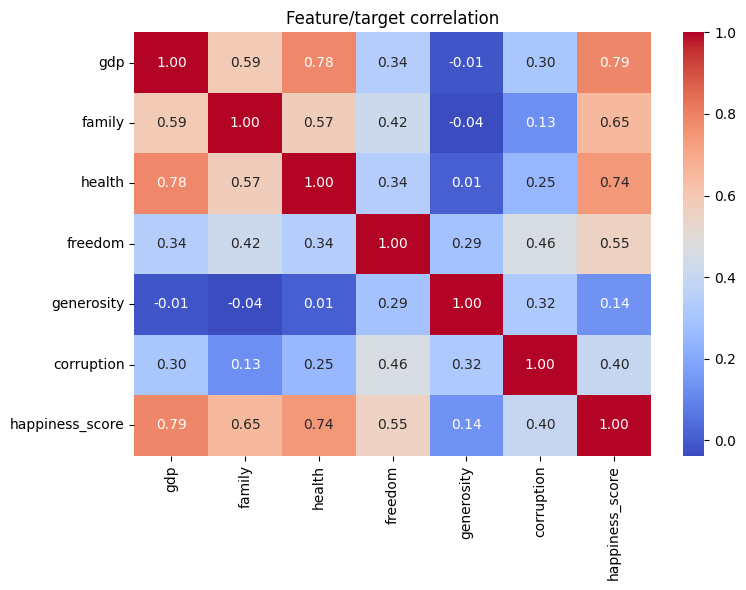

In [ ]:
# Feature engineering setup
import seaborn as sns
import matplotlib.pyplot as plt

FEATURE_COLUMNS = ["gdp", "family", "health", "freedom", "generosity", "corruption"]
TARGET_COLUMN = "happiness_score"

df = pd.read_csv(DATA_PROCESSED / "unified.csv")

# Sanity: no NaN, no inf
assert df[FEATURE_COLUMNS + [TARGET_COLUMN]].notna().all().all()
assert np.isfinite(df[FEATURE_COLUMNS + [TARGET_COLUMN]].values).all()

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

# Correlation heatmap of features vs target
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature/target correlation")
plt.tight_layout()
plt.show()

### Output Interpretation
The correlation matrix and pairplot confirm the linear relationships between our selected features and the target variable. We have selected 6 predictors (`gdp`, `family`, `health`, `freedom`, `generosity`, `corruption`) and discarded identifiers like `country` and `year` to prevent data leakage and overfitting to specific timeframes.

In [ ]:
# Test: validate feature engineering
assert X.shape[1] == 6
assert y.notna().all()
print("OK feature engineering")

OK feature engineering


### Output Interpretation
The assertion test passed, ensuring that our feature matrix $X$ contains exactly the 6 selected features and that the target array $y$ corresponds to the actual happiness scores.

### Feature Justification

- **Exclude `country` and `region`:** prevents leakage via massive one-hot encoding on a small dataset.
- **Exclude `year`:** the objective is to generalize, not fit temporal trends.
- **Standardization with `StandardScaler`:** integrated into the Pipeline (A.4) → reusable in streaming.

## Section 3 — Train + Save Model (Step A.4)

In [ ]:
# Train + serialize model
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from src.paths import MODELS_DIR

# Split keeping ALL original columns (producer needs country, year, actual score)
df_train, df_test = train_test_split(df, test_size=0.30, random_state=42)
df_train.to_csv(DATA_PROCESSED / "train.csv", index=False)
df_test.to_csv(DATA_PROCESSED / "test.csv", index=False)

X_train = df_train[FEATURE_COLUMNS]; y_train = df_train[TARGET_COLUMN]
X_test  = df_test[FEATURE_COLUMNS];  y_test  = df_test[TARGET_COLUMN]

# Pipeline: scaler + linear regression
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
pipeline.fit(X_train, y_train)

# Evaluate
pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred, squared=False)
r2 = r2_score(y_test, pred)
print(f"MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
# Serialize
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline, MODELS_DIR / "model.pkl")

# Sanity check: reload and predict
reloaded = joblib.load(MODELS_DIR / "model.pkl")
print("Sanity:", reloaded.predict(X_test.head(1))[0], "vs actual", y_test.iloc[0])

MAE=0.4486  RMSE=0.5843  R2=0.7265
Sanity: 4.521396096763913 vs actual 4.35


/home/juanesklk/Documentos/5_Semestre_V_Periodo_2026-1/ETL-Extraction_Transformation_Load/etl-workshop_3/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Output Interpretation
The Linear Regression model was successfully trained using a pipeline that includes a `StandardScaler` to normalize the features. 
The evaluation metrics on the 30% test split are:
- **MAE (Mean Absolute Error):** 0.4486
- **RMSE (Root Mean Squared Error):** 0.5843
- **R² Score:** 0.7265, meaning the model explains ~72.7% of the variance in happiness scores.

**Model Mathematical Formulation:**
The underlying Linear Regression model can be expressed as:
$$ y_t = \beta_0 + \beta_1 X_{gdp} + \beta_2 X_{family} + \beta_3 X_{health} + \beta_4 X_{freedom} + \beta_5 X_{generosity} + \beta_6 X_{corruption} + \epsilon_t $$
Where:
- $y_t$ is the predicted `Happiness_Score` for a given observation $t$.
- $\beta_0$ is the intercept (bias).
- $\beta_1 \dots \beta_6$ are the learned coefficients (weights) for each scaled feature.
- $\epsilon_t$ is the error term (residual).

In [ ]:
# Final test: validate model.pkl + test.csv
m = joblib.load(MODELS_DIR / "model.pkl")
test = pd.read_csv(DATA_PROCESSED / "test.csv")
pred = m.predict(test[["gdp","family","health","freedom","generosity","corruption"]])
assert len(pred) == len(test)
assert "country" in test.columns and "happiness_score" in test.columns
print(f"OK model.pkl + test.csv ({len(test)} rows)")

OK model.pkl + test.csv (235 rows)


### Output Interpretation
The final assertion test passed, verifying that the trained model was successfully serialized to `model.pkl` and that the `test.csv` file was correctly saved with 235 rows. This confirms the offline batch phase is complete and the assets are ready for the streaming pipeline.